# 14.1.2 投影动力学与新初值

## 学习目标与先修知识

把已知交换方程投影（projection）到低维坐标，分别检查训练重建、新初值（initial condition）误差和动态预测误差。

先修：14.1.1 投影与截断奇异值（singular value）；3.3 多室交换；2.4 显式 Euler 与步长。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

上一节的一个方向几乎无损重建训练轨迹（trajectory）。将已知三室交换方程直接投影到这个方向后，面对一个不同的初始分布（distribution），预测会怎样？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

把训练初值和新初值都投影到同一固定基上，先看 t=0 的差异，再检查后续演化。

In [2]:
mean=np.array([1.,1.,1.])
basis=np.array([[1.],[0.],[-1.]])/math.sqrt(2)
for name,x0 in [('训练初值',[2.,1.,0.]),('留出初值',[3.,0.,0.])]:
    x0=np.asarray(x0); projected=mean+basis@basis.T@(x0-mean)
    print(name,'初值投影误差',round(np.linalg.norm(x0-projected),6))

训练初值 初值投影误差 0.0
留出初值 初值投影误差 1.224745


## 模型假设

已知完整模型（model） $\dot x=-Lx$，$L$ 是三室对称交换拉普拉斯；没有外部输入（input），总量守恒。固定上一节仅由训练数据取得的中心 $\mu$ 与正交（orthogonality）列基 $U_r$，不针对留出初值重新拟合。中心和低维方向只由训练快照确定，不使用留出轨迹。本节随后利用已知完整方程 L 构造低维动态；后面的 DMD 再讨论如何从数据拟合动态。全模型与降阶模型用相同 Euler 步长比较，以分开截断与时间离散影响。

## 数学解释与推导

写 $x\approx\mu+U_ra$，把 $\dot x=-Lx$ 左乘 $U_r^\mathsf T$ 得 $\dot a=-U_r^\mathsf TL(\mu+U_ra)$，起始坐标 $a_0=U_r^\mathsf T(x_0-\mu)$。这称为 Galerkin 投影（Galerkin projection）的一个线性实例。显式一步为 $a_{k+1}=a_k-hU_r^\mathsf TL(\mu+U_ra_k)$；重建为 $\hat x_k=\mu+U_ra_k$。即使训练快照投影误差为零，新初值中被丢弃的方向也会在 $t=0$ 造成误差；滚动误差还可能放大。一室或两室的总量守恒并非任意基自动保留，需核对 $\mathbf1^\mathsf T\mu$ 及 $\mathbf1^\mathsf TU_r$。本例基只有零和差量方向，新初值总量等于训练总量，因此预测总量仍为 3 U；非负性（nonnegativity）也必须逐步检查。

## 核心实现

把上述步骤写成可检查的函数；算法在此处完整展示。

In [3]:
def centered_basis(snapshots, rank):
    """Fit mean and orthonormal basis on training columns only."""
    data = np.asarray(snapshots, dtype=float)
    mean = np.mean(data, axis=1)
    left, values, _ = np.linalg.svd(data - mean[:, None], full_matrices=False)
    return mean, left[:, :rank], values


def exchange_exact(laplacian, initial, times):
    """Exact trajectory for a symmetric closed exchange matrix."""
    lap = np.asarray(laplacian, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eigh(lap)
    x0 = np.asarray(initial, dtype=float)
    weights = eigenvectors.T @ x0
    return np.array([eigenvectors @ (np.exp(-eigenvalues * t) * weights) for t in times])


def reduced_euler(laplacian, basis, mean, initial, dt, steps):
    """Euler on a Galerkin projection; the first state is projected."""
    lap = np.asarray(laplacian, dtype=float)
    vectors = np.asarray(basis, dtype=float)
    center = np.asarray(mean, dtype=float)
    x0 = np.asarray(initial, dtype=float)
    coordinates = vectors.T @ (x0 - center)
    history = [(center + vectors @ coordinates).tolist()]
    for _ in range(steps):
        state = center + vectors @ coordinates
        coordinates = coordinates - dt * (vectors.T @ (lap @ state))
        history.append((center + vectors @ coordinates).tolist())
    return history


def full_euler(laplacian, initial, dt, steps):
    lap = np.asarray(laplacian, dtype=float)
    state = np.asarray(initial, dtype=float)
    history = [state.copy()]
    for _ in range(steps):
        state = state - dt * lap @ state
        history.append(state.copy())
    return np.asarray(history)

## 对照实验

把训练初值和独立新初值分别交给相同的降阶模型；与完整三室 Euler 轨迹和解析矩阵指数（matrix exponential）对照，图中展示新初值的逐时误差。

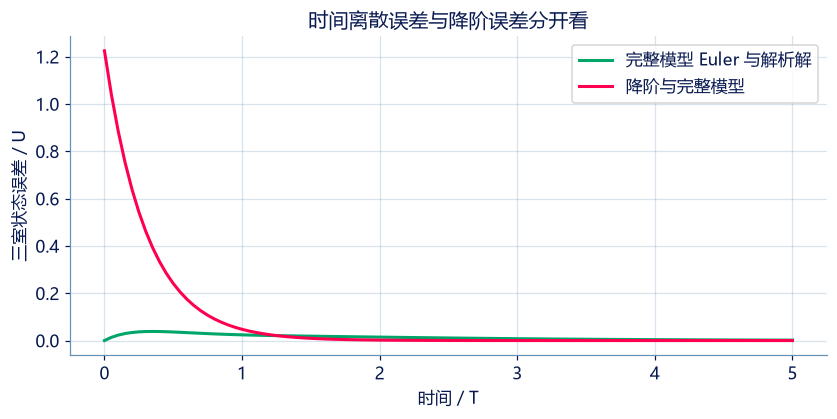

t=0 降阶误差 1.2247448713915898
t=5 降阶误差 1.07136684556261e-07


In [4]:
L=np.array([[1.,-1.,0.],[-1.,2.,-1.],[0.,-1.,1.]])
train=exchange_exact(L,[2.,1.,0.],np.linspace(0,6,31)).T
mean,basis,singular=centered_basis(train,1)
dt=.05;steps=100
full=full_euler(L,[3.,0.,0.],dt,steps)
reduced=np.asarray(reduced_euler(L,basis.tolist(),mean.tolist(),[3.,0.,0.],dt,steps))
exact=exchange_exact(L,[3.,0.,0.],np.arange(steps+1)*dt)
fig,ax=plt.subplots(figsize=(7.5,3.7))
ax.plot(np.arange(steps+1)*dt,np.linalg.norm(full-exact,axis=1),label='完整模型 Euler 与解析解',color=GREEN)
ax.plot(np.arange(steps+1)*dt,np.linalg.norm(reduced-full,axis=1),label='降阶与完整模型',color=PINK)
ax.set(xlabel='时间 / T',ylabel='三室状态误差 / U',title='时间离散误差与降阶误差分开看')
ax.legend();ax.grid(alpha=.25);plt.show()
print('t=0 降阶误差',np.linalg.norm(reduced[0]-full[0]))
print('t=5 降阶误差',np.linalg.norm(reduced[-1]-full[-1]))

## 结果解释

完整模型 Euler 与解析解（analytical solution）的差随所选步长较小；降阶模型从 t=0 已有明显误差，不能把它归因于 Euler。新初值同时激发训练未见的快方向；秩（rank）1训练重建成功不能证明新初值可预测。

### 独立核对

先用固定手算基核对一步坐标更新；再核对总量、训练初值极限（limit）和缩小步长后的误差来源。

In [5]:
simple=reduced_euler([[1.,-1.],[-1.,1.]],[[1/math.sqrt(2)],[-1/math.sqrt(2)]],[1.,1.],[2.,0.],.1,1)
np.testing.assert_allclose(simple,[[2.,0.],[1.8,.2]],atol=1e-12)
np.testing.assert_allclose(reduced.sum(axis=1),3.,atol=1e-10)
assert np.linalg.norm(reduced[0]-full[0])>.5
assert np.linalg.norm(full[-1]-exact[-1])<.02
print('手算一步、总量和误差来源核验通过。')

手算一步、总量和误差来源核验通过。


[在本章探索中改变截断秩与初值](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/explore/)：先预测，再检查重建和留出误差。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：已知方程的降阶显式更新

完整模型（model）满足 dx/dt=−Lx。给定正交（orthogonality）列基 basis、中心 mean 和初始状态（state） initial，把初值（initial condition）先投影（projection），再对降阶坐标做 steps 次显式 Euler 更新；返回含投影初态的每步 n 维重建状态。

**函数与代码模板**

```python
def solve(
    laplacian: list[list[float]],
    basis: list[list[float]],
    mean: list[float],
    initial: list[float],
    dt: float,
    steps: int,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `laplacian` | `list[list[float]]` | 已知 n×n 对称交换拉普拉斯。 | 1/T |
| `basis` | `list[list[float]]` | n×r 正交列基，r 至少1。 | 1 |
| `mean` | `list[float]` | 训练得到的 n 维中心；本题直接给出。 | U |
| `initial` | `list[float]` | 新条件下的 n 维初始总量。 | U |
| `dt` | `float` | 正时间步。 | T |
| `steps` | `int` | 非负更新步数。 | 步 |

**返回值**

直接返回 history（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 投影初态及之后每一步的重建状态，共 steps+1 行。 | U |

**计算规则**

a0=basisᵀ(initial−mean)；每步只读旧 a，用 a_next=a−dt·basisᵀ L(mean+basis·a) 更新；返回 mean+basis·a。题给 basis 已正交，不重拟合。

**约束与边界**

- 输入（input）矩阵（matrix）有限；按照给定秩（rank）与顺序返回普通 Python 列表及浮点数。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| laplacian | 已知 n×n 对称交换拉普拉斯。 | [[1.0, -1.0], [-1.0, 1.0]] | 1/T |
| basis | n×r 正交列基，r 至少1。 | [[1.0], [0.0]] | 1 |
| mean | 训练得到的 n 维中心；本题直接给出。 | [0.0, 0.0] | U |
| initial | 新条件下的 n 维初始总量。 | [2.0, 0.0] | U |
| dt | 正时间步。 | 0.1 | T |
| steps | 非负更新步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
laplacian = [[1.0, -1.0], [-1.0, 1.0]]
basis = [[1.0], [0.0]]
mean = [0.0, 0.0]
initial = [2.0, 0.0]
dt = 0.1
steps = 2

result = solve(laplacian, basis, mean, initial, dt, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 投影初态及之后每一步的重建状态，共 steps+1 行。 | [[2.0, 0.0], [1.8, 0.0], [1.62, 0.0]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[2.0, 0.0], [1.8, 0.0], [1.62, 0.0]]
```

**样例解释**

首例初值落在给定基上；一步后第一室为1.8 U、第二室为0，第二步为1.62 U 与0。降阶结果不自动保留完整模型的守恒。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：已知方程的降阶显式更新](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-galerkin-euler)

### 第 2 题 · 单项选择题：预测误差从何时开始

训练轨迹（trajectory）的秩（rank）1重建残差（residual）接近0，但新初值（initial condition）有一个与训练基正交（orthogonality）的分量。哪项判断正确？

- **A.** 降阶重建在初始时刻就可能与新初值不同。
- **B.** 训练残差为零保证新初值初始误差也为零。
- **C.** 这一定是 Euler 步长造成的。
- **D.** 提高绘图分辨率可恢复被丢弃的方向。

[作答：预测误差从何时开始](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-initial-projection)

### 第 3 题 · 单项选择题：投影后是否仍守恒

完整无输入（input）交换方程的总量守恒。一个任意低秩（rank）投影（projection）模型（model）是否因此自动守恒且非负？

- **A.** 不能自动保证；要检查基、中心、离散步长与重建状态（state）。
- **B.** 任何正交投影（orthogonal projection）都自动保留总量并保持每一室非负。
- **C.** 只要训练重建误差小，所有新轨迹（trajectory）必满足守恒和非负。
- **D.** 舍弃奇异值（singular value）平方和就是总量收支（mass balance）残差（residual）。

[作答：投影后是否仍守恒](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-conservation-projection)

### 第 4 题 · 单项选择题：区分时间误差与降阶误差

同一新初值（initial condition）下，完整模型（model）的 Euler 轨迹（trajectory）与解析解（analytical solution）接近，降阶 Euler 轨迹却从 t=0 起偏离完整模型。优先检查什么？

- **A.** 初值投影（projection）和训练基覆盖范围，再单独检查步长细化。
- **B.** 只缩小绘图采样（sampling）间隔。
- **C.** 宣布完整解析解错误。
- **D.** 只看训练重建能量，忽略新初值。

[作答：区分时间误差与降阶误差](http://127.0.0.1:8000/chapters/14-01-%E4%BD%8E%E7%A7%A9%E5%88%86%E8%A7%A3%E4%B8%8E%E6%A8%A1%E5%9E%8B%E9%99%8D%E9%98%B6/practice/?question=p14-time-vs-reduction)

**进一步阅读**

[Brunton 与 Kutz 的数据驱动科学教材](https://www.cambridge.org/highereducation/books/data-driven-science-and-engineering/6F9A730B7A9A9F43F68CF21A24BEC339/contents/F7A59AEF64F3A226EEADD2F1DDD4F083)提供模型降阶的背景。